In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import globals as gl
import os
from Plot import make_yref, set_spines_and_ticks_width

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


ModuleNotFoundError: No module named 'SUITPy'

/tmp/ipykernel_36989/2082415795.py:25: RuntimeWarning: Mean of empty slice.
  force_tmp = force[(dat.cue == cue) & (dat.stimFinger == stimF) & (dat.GoNogo == 'go'), f].mean(axis=0, keepdims=True).squeeze()
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


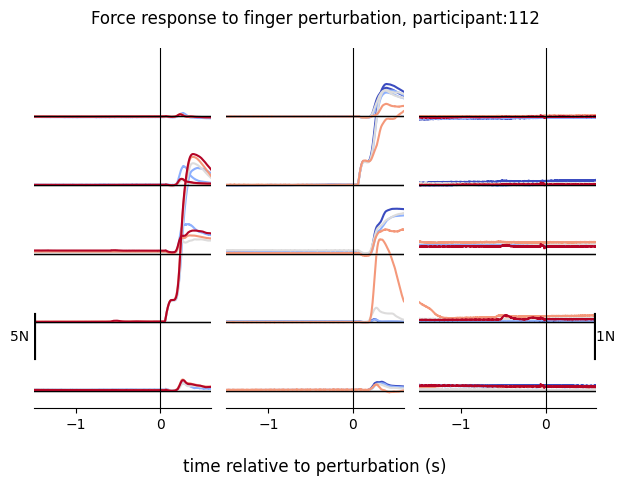

In [8]:
experiment = 'smp2'
sn = 112
vsep_go = 8
vsep_nogo = 1.6

pinfo = pd.read_csv(os.path.join(gl.baseDir, experiment, 'participants.tsv'), sep='\t')
runs = pinfo[pinfo['sn']==sn].FuncRuns.reset_index(drop=True)[0].split('.')

dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
dat = dat[dat['BN'].astype(str).isin(runs)]

npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_segmented.npz'))
force = npz['data_array']

fig, axs = plt.subplots(ncols=3, sharex=True)

cmap = plt.get_cmap("coolwarm")
colors = [cmap(i) for i in np.linspace(0, 1, force.shape[1])]

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for c, cue in enumerate(gl.cue_code):
    for sf, stimF in enumerate(gl.stimFinger_code):
        for f in range(force.shape[1]):
            force_tmp = force[(dat.cue == cue) & (dat.stimFinger == stimF) & (dat.GoNogo == 'go'), f].mean(axis=0, keepdims=True).squeeze()
            axs[sf].plot(tAx, force_tmp + f * vsep_go, color=colors[c])
            axs[sf].axhline(f * vsep_go, color='k', lw=.8)

axs[0].spines[['top', 'right', 'left']].set_visible(False)
axs[0].axvline(0, ls='-', color='k', lw=.8)
axs[0].set_yticks([])

axs[1].spines[['top', 'right', 'left']].set_visible(False)
axs[1].axvline(0, ls='-', color='k', lw=.8)
axs[1].set_yticks([])

axs[0].set_xlim([-.5, .6])
axs[0].set_ylim([-2, 40])
axs[1].set_ylim([-2, 40])
axs[2].set_ylim([-.4, 8])

for c, cue in enumerate(gl.cue_code):
    for f in range(force.shape[1]):
        force_tmp = force[(dat.cue == cue) & (dat.GoNogo == 'nogo'), f].mean(axis=0, keepdims=True).squeeze()
        axs[2].plot(tAx, force_tmp + f * vsep_nogo, color=colors[c])
        axs[2].axhline(f * vsep_nogo, color='k', lw=.8)

axs[2].spines[['top', 'right', 'left']].set_visible(False)
axs[2].axvline(0, ls='-', color='k', lw=.8)
axs[2].set_yticks([])

make_yref(axs[0], reference_length=5, pos='left')
make_yref(axs[2], reference_length=1, pos='right')

fig.supxlabel('time relative to perturbation (s)')

fig.suptitle(f'Force response to finger perturbation, participant:{sn}')

fig.tight_layout()

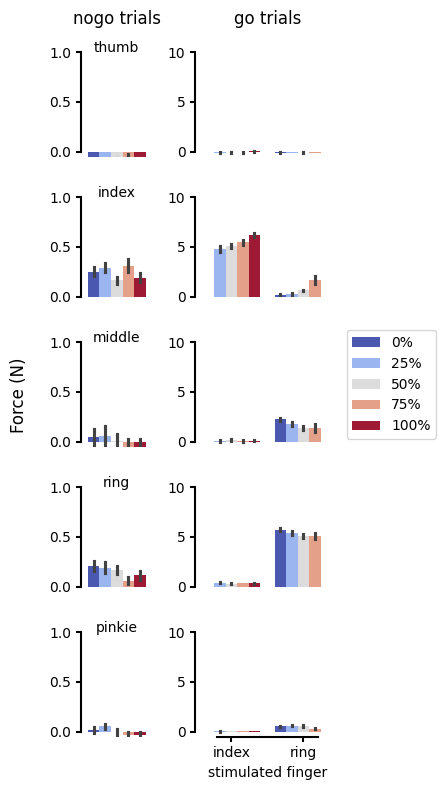

In [12]:
sn = 103
experiment = 'smp2'

df = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')

# df = df.groupby(['stimFinger', 'cue', 'GoNogo',]).mean(numeric_only=True).reset_index()
df['cue'] = df['cue'].map(gl.cue_mapping)
df['stimFinger'] = df['stimFinger'].map(gl.stimFinger_mapping)

fig, axs = plt.subplots(5, 2, figsize=(4.5, 8), gridspec_kw={'width_ratios': [1, 2]})

for f, finger in enumerate(gl.channels['mov']):
    if f==2:
        sns.barplot(x='stimFinger', y=finger + '1', ax=axs[f, 1], hue='cue', data=df[df['GoNogo']=='go'], legend=True, order=['index', 'ring'],hue_order=gl.cues, palette=list(gl.colour_mapping.values())[:5], errorbar='se')
    else:
        sns.barplot(x='stimFinger', y=finger + '1', ax=axs[f, 1], hue='cue', data=df[df['GoNogo']=='go'], legend=False, order=['index', 'ring'],hue_order=gl.cues, palette=list(gl.colour_mapping.values())[:5], errorbar='se')

    axs[f, 1].set_ylim([-.5, 12])
    axs[f, 1].set_xlabel('')
    axs[f, 1].set_ylabel('')
    # axs[f, 1].set_title(finger)
    axs[f, 1].spines[['left',]].set_bounds(0, 10)

    if f<4:
        axs[f, 1].set_xticks([])
        axs[f, 1].spines[['bottom','right','top']].set_visible(False)

    if f==0:
        axs[f, 1].set_title(f'go trials')

for f, finger in enumerate(gl.channels['mov']):
    sns.barplot(x='stimFinger', y=finger + '0', ax=axs[f, 0], hue='cue', data=df[df['GoNogo']=='nogo'], legend=False, hue_order=gl.cues, palette=list(gl.colour_mapping.values())[:5], errorbar='se')

    axs[f, 0].set_ylim([-.05, 1.2])
    axs[f, 0].set_xlabel('')
    axs[f, 0].set_ylabel('')
    axs[f, 0].text(0, 1, finger, ha='center')
    axs[f, 0].spines[['left',]].set_bounds(0, 1)

    axs[f, 0].set_xticks([])
    axs[f, 0].spines[['bottom','right','top']].set_visible(False)

    if f==0:
        axs[f, 0].set_title(f'nogo trials')

axs[-1, -1].set_xlabel('stimulated finger')
axs[-1, -1].spines[['right','top']].set_visible(False)
axs[-1, -1].spines[['bottom',]].set_bounds(-.2, 1.2)
axs[2, 1].legend(loc='center left', bbox_to_anchor=(1, 0.5), )

for row in range(5):
    for col in range(2):
        set_spines_and_ticks_width(axs[row, col], spine_width=1.5,spine_sides=('bottom', 'left'), tick_width=1.5,axes=('x', 'y'),which='both')

fig.supylabel('Force (N)')
fig.tight_layout()


ValueError: Could not interpret value `thumb` for `y`. An entry with this name does not appear in `data`.

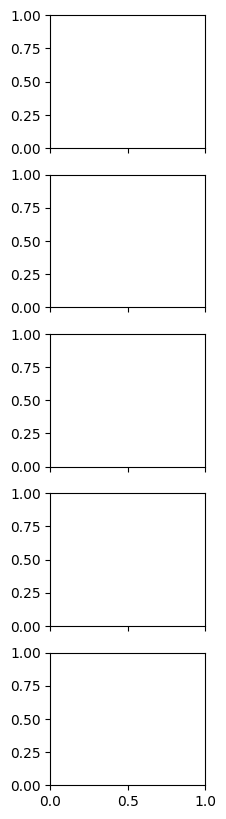

In [10]:
experiment = 'smp2'
sn = 109

force_df = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
force_df['cue'] = force_df['cue'].map(gl.cue_mapping)
force_df['stimFinger'] = force_df['stimFinger'].map(gl.stimFinger_mapping)

fingers = ['thumb', 'index', 'middle', 'ring', 'pinkie']

fig, axs = plt.subplots(len(fingers), sharex=True, sharey=True, figsize=(2, 10))

for f, finger in enumerate(fingers):

    sns.boxplot(y=finger, ax=axs[f], hue='cue',data=force_df[force_df['GoNogo']=='nogo'], hue_order=list(gl.cue_mapping.values()), showfliers=False, palette=colors, legend=False)
    axs[f].axhline(0, ls='-', color='k', lw=.8)

    axs[f].set_xlabel('')
    axs[f].set_ylabel('')
    axs[f].set_title(finger)

fig.supylabel('force (N)')
fig.tight_layout()